In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast

In [10]:
# 1. LOAD THE CREDITS FILE
df = pd.read_csv('tmdb_5000_credits.csv')

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head(2))

Columns: ['movie_id', 'title', 'cast', 'crew']
Shape: (4803, 4)
   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  


In [11]:
# 2. PARSE JSON COLUMNS
def parse_json(cell):
    """Safely parse a JSON/string list column."""
    try:
        return ast.literal_eval(cell)
    except:
        return []

df['cast_parsed'] = df['cast'].apply(parse_json)
df['crew_parsed'] = df['crew'].apply(parse_json)


In [12]:
# 3. EXTRACT USEFUL FIELDS
# Extract director from crew
def get_director(crew_list):
    for member in crew_list:
        if member.get('job') == 'Director':
            return member.get('name')
    return None

# Extract top 3 cast names
def get_top_cast(cast_list, n=3):
    sorted_cast = sorted(cast_list, key=lambda x: x.get('order', 99))
    return [c['name'] for c in sorted_cast[:n]]

# Extract cast size
def get_cast_size(cast_list):
    return len(cast_list)

# Extract number of departments in crew
def get_crew_size(crew_list):
    return len(crew_list)

df['director']   = df['crew_parsed'].apply(get_director)
df['top_cast']   = df['cast_parsed'].apply(get_top_cast)
df['cast_size']  = df['cast_parsed'].apply(get_cast_size)
df['crew_size']  = df['crew_parsed'].apply(get_crew_size)
df['lead_actor'] = df['cast_parsed'].apply(lambda x: x[0]['name'] if x else None)

print("\nExtracted fields sample:")
print(df[['title','director','lead_actor','cast_size','crew_size']].head(5))




Extracted fields sample:
                                      title           director  \
0                                    Avatar      James Cameron   
1  Pirates of the Caribbean: At World's End     Gore Verbinski   
2                                   Spectre         Sam Mendes   
3                     The Dark Knight Rises  Christopher Nolan   
4                               John Carter     Andrew Stanton   

        lead_actor  cast_size  crew_size  
0  Sam Worthington         83        153  
1      Johnny Depp         34         32  
2     Daniel Craig         83        155  
3   Christian Bale        158        217  
4    Taylor Kitsch         27        132  


In [13]:
# 4. SUMMARY STATISTICS
print("\n── Cast Size Stats ──")
print(df['cast_size'].describe())

print("\n── Crew Size Stats ──")
print(df['crew_size'].describe())

print("\n── Top 10 Directors by Number of Movies ──")
top_directors = df['director'].value_counts().head(10)
print(top_directors)

print("\n── Top 10 Lead Actors by Appearances ──")
top_actors = df['lead_actor'].value_counts().head(10)
print(top_actors)


── Cast Size Stats ──
count    4803.000000
mean       22.123048
std        19.582493
min         0.000000
25%        11.000000
50%        16.000000
75%        25.000000
max       224.000000
Name: cast_size, dtype: float64

── Crew Size Stats ──
count    4803.000000
mean       26.979180
std        31.628564
min         0.000000
25%         8.000000
50%        16.000000
75%        32.000000
max       435.000000
Name: crew_size, dtype: float64

── Top 10 Directors by Number of Movies ──
director
Steven Spielberg     27
Woody Allen          21
Martin Scorsese      20
Clint Eastwood       20
Ridley Scott         16
Robert Rodriguez     16
Spike Lee            16
Steven Soderbergh    15
Renny Harlin         15
Tim Burton           14
Name: count, dtype: int64

── Top 10 Lead Actors by Appearances ──
lead_actor
Bruce Willis             30
Robert De Niro           30
Nicolas Cage             29
Johnny Depp              27
Denzel Washington        26
Tom Hanks                24
Tom Cruise     

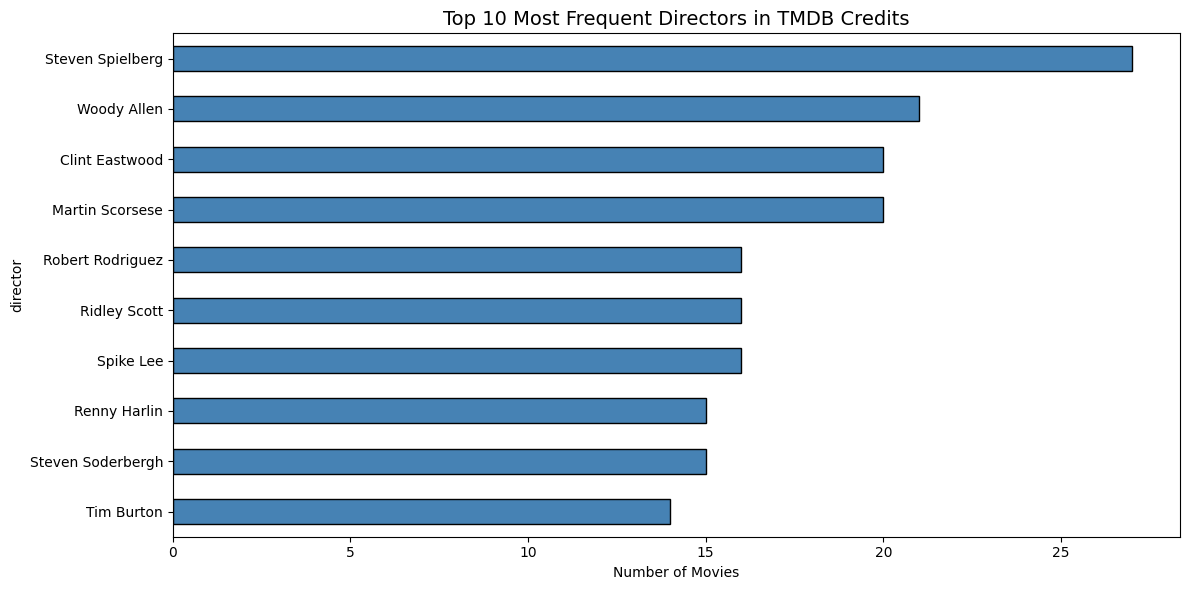

Saved: top_directors.png


In [14]:
# 5. PLOT 1 — Top 10 Directors (Bar Chart)
plt.figure(figsize=(12, 6))
top_directors.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Most Frequent Directors in TMDB Credits', fontsize=14)
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('top_directors.png', dpi=150)
plt.show()
print("Saved: top_directors.png")

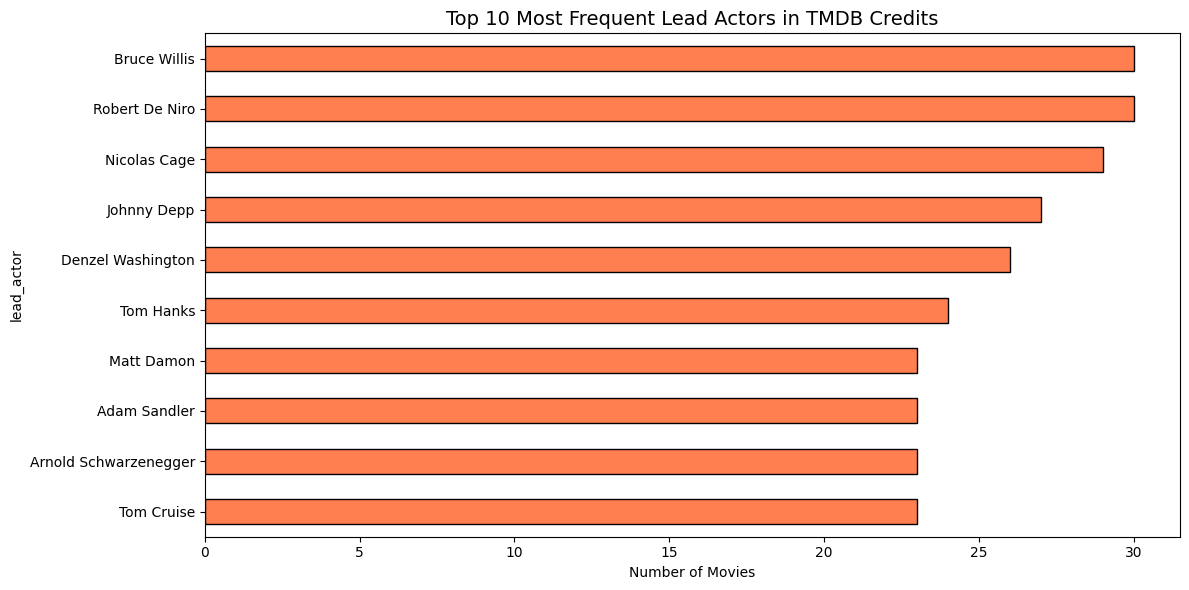

Saved: top_actors.png


In [21]:
# 6. PLOT 2 — Top 10 Lead Actors (Bar Chart)
plt.figure(figsize=(12, 6))
top_actors.sort_values().plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Most Frequent Lead Actors in TMDB Credits', fontsize=14)
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('top_actors.png', dpi=150)
plt.show()
print("Saved: top_actors.png")


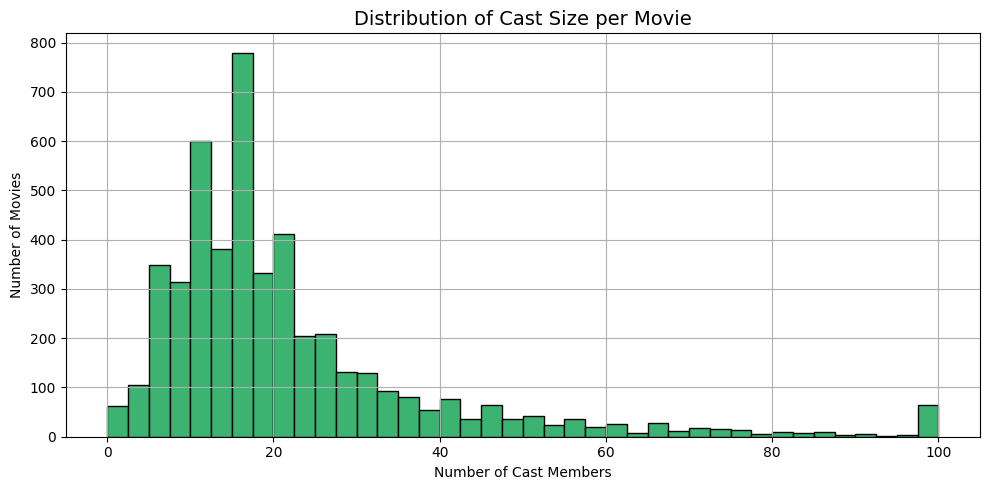

Saved: cast_size_dist.png


In [16]:
# 7. PLOT 3 — Cast Size Distribution
plt.figure(figsize=(10, 5))
df['cast_size'].clip(upper=100).hist(bins=40, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Cast Size per Movie', fontsize=14)
plt.xlabel('Number of Cast Members')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('cast_size_dist.png', dpi=150)
plt.show()
print("Saved: cast_size_dist.png")


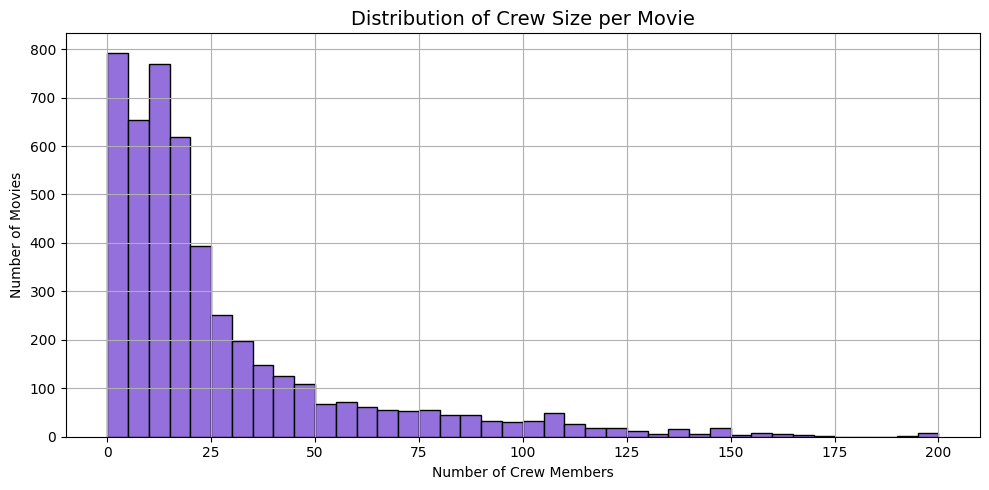

Saved: crew_size_dist.png


In [17]:
# 8. PLOT 4 — Crew Size Distribution
plt.figure(figsize=(10, 5))
df['crew_size'].clip(upper=200).hist(bins=40, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Crew Size per Movie', fontsize=14)
plt.xlabel('Number of Crew Members')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('crew_size_dist.png', dpi=150)
plt.show()
print("Saved: crew_size_dist.png")

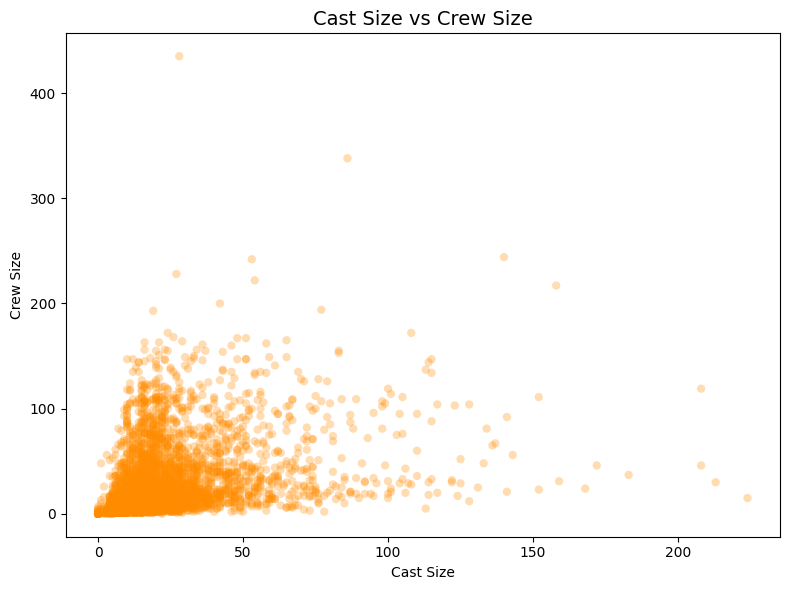

Saved: cast_vs_crew.png


In [18]:
# 9. PLOT 5 — Cast vs Crew Size Scatter
plt.figure(figsize=(8, 6))
plt.scatter(df['cast_size'], df['crew_size'], alpha=0.3, color='darkorange', edgecolors='none')
plt.title('Cast Size vs Crew Size', fontsize=14)
plt.xlabel('Cast Size')
plt.ylabel('Crew Size')
plt.tight_layout()
plt.savefig('cast_vs_crew.png', dpi=150)
plt.show()
print("Saved: cast_vs_crew.png")

In [20]:
# 10. EXPORT TO EXCEL
df['top_cast_str'] = df['top_cast'].apply(lambda x: ', '.join(x))

export_df = df[['movie_id', 'title', 'director', 'lead_actor',
                 'top_cast_str', 'cast_size', 'crew_size']].copy()
export_df.columns = ['Movie ID', 'Title', 'Director', 'Lead Actor',
                      'Top 3 Cast', 'Cast Size', 'Crew Size']

with pd.ExcelWriter('tmdb_credits_analysis.xlsx', engine='openpyxl') as writer:

    # Sheet 1: Full cleaned data
    export_df.to_excel(writer, sheet_name='All Movies', index=False)

    # Sheet 2: Top Directors
    top_dir_df = df['director'].value_counts().head(20).reset_index()
    top_dir_df.columns = ['Director', 'Movie Count']
    top_dir_df.to_excel(writer, sheet_name='Top Directors', index=False)

    # Sheet 3: Top Lead Actors
    top_act_df = df['lead_actor'].value_counts().head(20).reset_index()
    top_act_df.columns = ['Lead Actor', 'Appearances']
    top_act_df.to_excel(writer, sheet_name='Top Lead Actors', index=False)

    # Sheet 4: Cast & Crew Size Summary
    summary = pd.DataFrame({
        'Metric': ['Avg Cast Size', 'Max Cast Size', 'Min Cast Size',
                   'Avg Crew Size', 'Max Crew Size', 'Min Crew Size'],
        'Value': [
            df['cast_size'].mean().round(1), df['cast_size'].max(), df['cast_size'].min(),
            df['crew_size'].mean().round(1), df['crew_size'].max(), df['crew_size'].min()
        ]
    })
    summary.to_excel(writer, sheet_name='Summary Stats', index=False)

print("\n✅ Done! Excel saved as: tmdb_credits_analysis.xlsx")
print("📊 Charts saved as PNG files.")




✅ Done! Excel saved as: tmdb_credits_analysis.xlsx
📊 Charts saved as PNG files.
